## Config

In [1]:
from src.core.config import Config

In [2]:
config = Config()
config

Config(path='C:\Project\Minor Project Traffic Surveillance\traffic_surveillance\track1\config.yaml')

## Video Loader

In [3]:
from src.input.video_loader import VideoLoader
from pathlib import Path

In [4]:
config["paths"]["video"]

'data/raw/sample.avi'

In [6]:
videoloader_initialized = VideoLoader(config["paths"]["video"])

2026-07-20 04:27:49,187 | INFO     | src.input.video_loader | Loaded video 'sample.avi' | 1280x720 | 10.00 FPS | 2001 frames | 200.10 sec | Codec: FMP4


In [7]:
print('capture: ', videoloader_initialized._capture)

capture:  < cv2.VideoCapture 000001AA96548750>


In [8]:
# public methods
print(videoloader_initialized.is_opened())
print(videoloader_initialized.read())

True
(True, array([[[ 83,  70,  66],
        [ 83,  70,  66],
        [ 83,  70,  66],
        ...,
        [167, 124,  95],
        [167, 124,  95],
        [167, 124,  95]],

       [[ 83,  70,  66],
        [ 83,  70,  66],
        [ 83,  70,  66],
        ...,
        [167, 124,  95],
        [167, 124,  95],
        [167, 124,  95]],

       [[ 84,  71,  67],
        [ 84,  71,  67],
        [ 84,  71,  67],
        ...,
        [167, 124,  95],
        [167, 124,  95],
        [167, 124,  95]],

       ...,

       [[120, 114, 117],
        [120, 114, 117],
        [120, 114, 117],
        ...,
        [109, 106, 105],
        [102,  99,  98],
        [ 98,  95,  94]],

       [[120, 114, 117],
        [120, 114, 117],
        [120, 114, 117],
        ...,
        [117, 114, 113],
        [110, 107, 106],
        [105, 102, 101]],

       [[120, 114, 117],
        [120, 114, 117],
        [120, 114, 117],
        ...,
        [123, 120, 119],
        [118, 115, 114],
        [114

In [9]:
videoloader_initialized.get_frame(2)

array([[[ 83,  70,  66],
        [ 83,  70,  66],
        [ 83,  70,  66],
        ...,
        [167, 124,  93],
        [167, 124,  93],
        [167, 124,  93]],

       [[ 83,  70,  66],
        [ 83,  70,  66],
        [ 83,  70,  66],
        ...,
        [167, 124,  93],
        [167, 124,  93],
        [167, 124,  93]],

       [[ 84,  71,  67],
        [ 84,  71,  67],
        [ 84,  71,  67],
        ...,
        [167, 124,  95],
        [167, 124,  95],
        [167, 124,  95]],

       ...,

       [[120, 114, 117],
        [120, 114, 117],
        [118, 114, 117],
        ...,
        [109, 106, 105],
        [102,  99,  98],
        [ 98,  95,  94]],

       [[120, 114, 117],
        [120, 114, 117],
        [118, 114, 117],
        ...,
        [117, 114, 113],
        [110, 107, 106],
        [105, 102, 101]],

       [[120, 114, 117],
        [120, 114, 117],
        [118, 114, 117],
        ...,
        [123, 120, 119],
        [118, 115, 114],
        [114, 111, 110]]

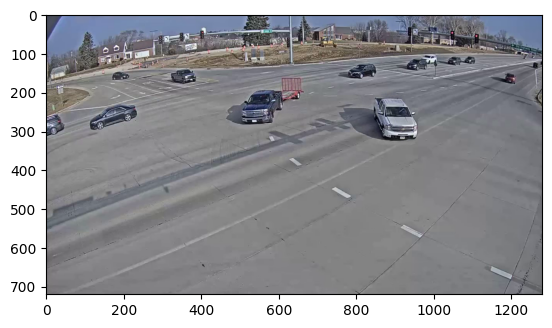

In [10]:
import matplotlib.pyplot as plt
import cv2

frame2 = videoloader_initialized.get_frame(2)
frame = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
frame = plt.imshow(frame)
plt.show()

Video metadata

## Detector

In [11]:
from src.detection.ultralytics_detector import UltralyticsDetector

In [12]:
config["detection"]

{'algorithm': 'ultralytics',
 'backend': 'yolo',
 'model': 'models/yolo11n.pt',
 'iou': 0.45,
 'confidence': 0.25,
 'device': 'cpu',
 'classes': ['car', 'bus', 'truck', 'motorcycle']}

In [13]:
yolo_initialized = UltralyticsDetector(config)

In [14]:
# Attributes
print('backend: ', yolo_initialized._backend)
print('confidence: ', yolo_initialized._confidence)
print('iou :', yolo_initialized._iou)
print('decide :', yolo_initialized._device)
print('allowed classes: ', yolo_initialized._allowed_classes)

backend:  yolo
confidence:  0.25
iou : 0.45
decide : cpu
allowed classes:  {'truck', 'motorcycle', 'car', 'bus'}


In [15]:
yolo_detections = yolo_initialized.detect(frame2)
yolo_detections

[Detection(bbox=BoundingBox(x1=112.881, y1=228.362, x2=235.621, y2=296.636), confidence=0.7337390184402466, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=777.447, y1=128.207, x2=852.076, y2=165.138), confidence=0.7200058698654175, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=322.254, y1=140.614, x2=388.323, y2=178.483), confidence=0.7151513695716858, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=0.0, y1=255.968, x2=47.689, y2=312.556), confidence=0.7014424204826355, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=501.815, y1=193.516, x2=610.394, y2=280.828), confidence=0.6737852096557617, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=168.659, y1=147.815, x2=217.67, y2=171.001), confidence=0.6016750335693359, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=930.427, y1=105.287, x2=1011.256, y2=144.472), confidence=0.5898547768592834, class_id=2, class_name='car'),
 Detection(bbox=BoundingBox(x1=1

## Visualizer

In [32]:
from src.visualization.detector_visualizer import BenchmarkVisualizer

output_path = Path("outputs/test/yolo11n.mp4")
fps = 30
frame_width = 1280
frame_height = 720
detector_name = "Yolo11n"

visualization_initialized = BenchmarkVisualizer(output_video, fps, frame_width, frame_height, detector_name)
visualization_initialized

In [17]:
# Attributes
visualization_initialized.detector_name

'Yolo11n'

In [18]:
visualization_initialized.writer

< cv2.VideoWriter 000001AACB1B35F0>

In [19]:
annotated_frame2 = visualization_initialized.draw(frame2, yolo_detections, fps, 2)

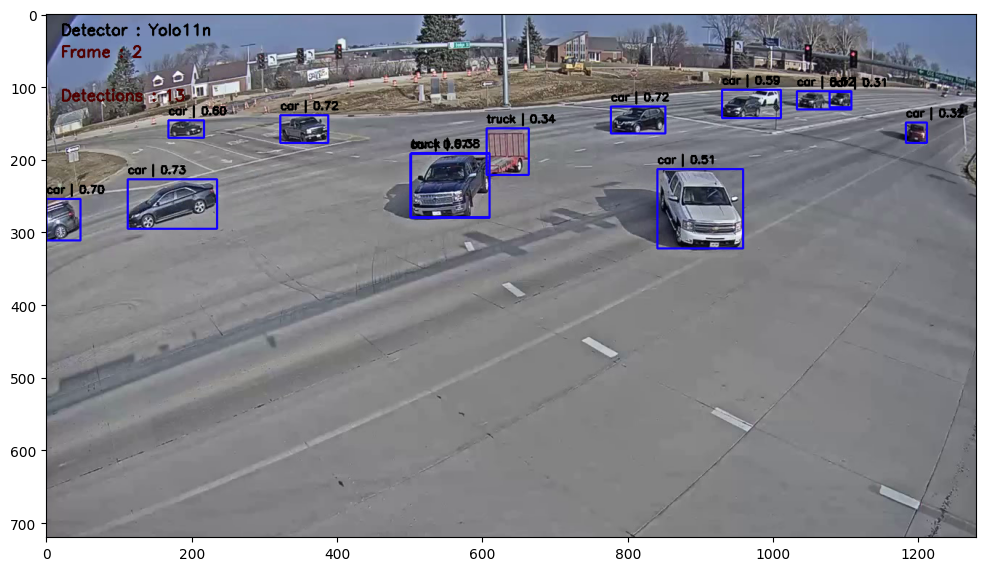

In [22]:
plt.figure(figsize=(12, 8))
frame = cv2.cvtColor(annotated_frame2, cv2.COLOR_BGR2RGB)
plt.imshow(frame)
plt.show()

## Tracking

In [24]:
from src.tracking.bytetrack_tracker import ByteTrackTracker

In [26]:
tracker_intialized = ByteTrackTracker(config)
tracker_intialized

In [28]:
# Attributes
print(tracker_intialized.cfg)
print(tracker_intialized._active_tracks)
print(tracker_intialized._tracker)

{'track_activation_threshold': 0.25, 'lost_track_buffer': 30, 'minimum_matching_threshold': 0.8, 'frame_rate': 10}
[]


In [38]:
tracks = tracker_intialized.update(yolo_detections)

In [39]:
tracks

[Track(bbox=BoundingBox(x1=112.88099670410156, y1=228.36199951171875, x2=235.62100219726562, y2=296.635986328125), confidence=0.7337390184402466, class_id=2, class_name='car', track_id=1, state=<TrackState.ACTIVE: 'active'>, age=1, lost_frames=0, history=()),
 Track(bbox=BoundingBox(x1=777.447021484375, y1=128.20700073242188, x2=852.0759887695312, y2=165.13800048828125), confidence=0.7200058698654175, class_id=2, class_name='car', track_id=2, state=<TrackState.ACTIVE: 'active'>, age=1, lost_frames=0, history=()),
 Track(bbox=BoundingBox(x1=322.2539978027344, y1=140.61399841308594, x2=388.322998046875, y2=178.48300170898438), confidence=0.7151513695716858, class_id=2, class_name='car', track_id=3, state=<TrackState.ACTIVE: 'active'>, age=1, lost_frames=0, history=()),
 Track(bbox=BoundingBox(x1=0.0, y1=255.96800231933594, x2=47.68899917602539, y2=312.5559997558594), confidence=0.7014424204826355, class_id=2, class_name='car', track_id=4, state=<TrackState.ACTIVE: 'active'>, age=1, lost_

### Visualization

In [ ]:
from src.visualization.visualizer import Visualizer

visualization_initialized = Visualizer(
    show_labels = True,
    show_track_id = True,
    output_video = output_path,
    fps = fps,
    frame_width = frame_width,
    frame_height = frame_height,
)
visualization_initialized

In [43]:
full_annotated_frame2 = visualization_initialized.draw_tracks(frame2, tracks, frame_number = 2)

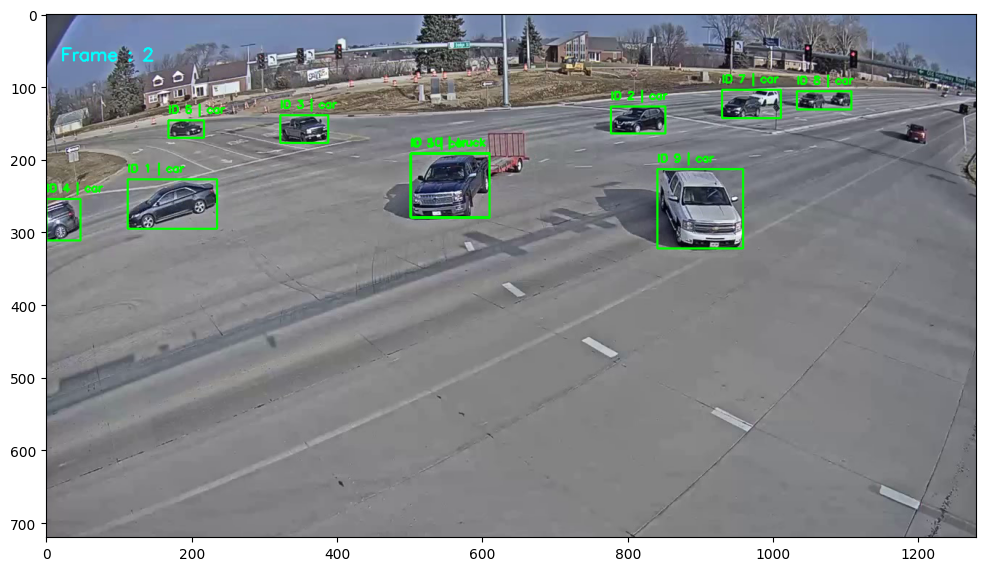

In [45]:
plt.figure(figsize=(12, 8))
frame = cv2.cvtColor(full_annotated_frame2, cv2.COLOR_BGR2RGB)
plt.imshow(frame)
plt.show()

## Tracking Test

In [46]:
# Configuration

from src.core.config import Config
from src.input.video_loader import VideoLoader

config = Config()

2026-07-20 05:06:53,602 | INFO     | src.input.video_loader | Loaded video 'sample.avi' | 1280x720 | 10.00 FPS | 2001 frames | 200.10 sec | Codec: FMP4
2026-07-20 05:06:53,623 | INFO     | src.input.video_loader | Released video sample.avi.


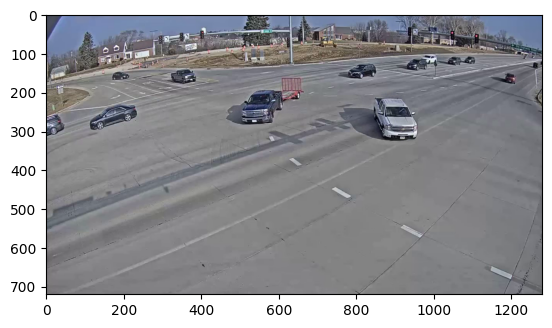

In [47]:
# Video Loader

videoloader_initialized = VideoLoader(config["paths"]["video"])
frame2 = videoloader_initialized.get_frame(2)

import matplotlib.pyplot as plt
import cv2

frame = cv2.cvtColor(frame2, cv2.COLOR_BGR2RGB)
frame = plt.imshow(frame)
plt.show()

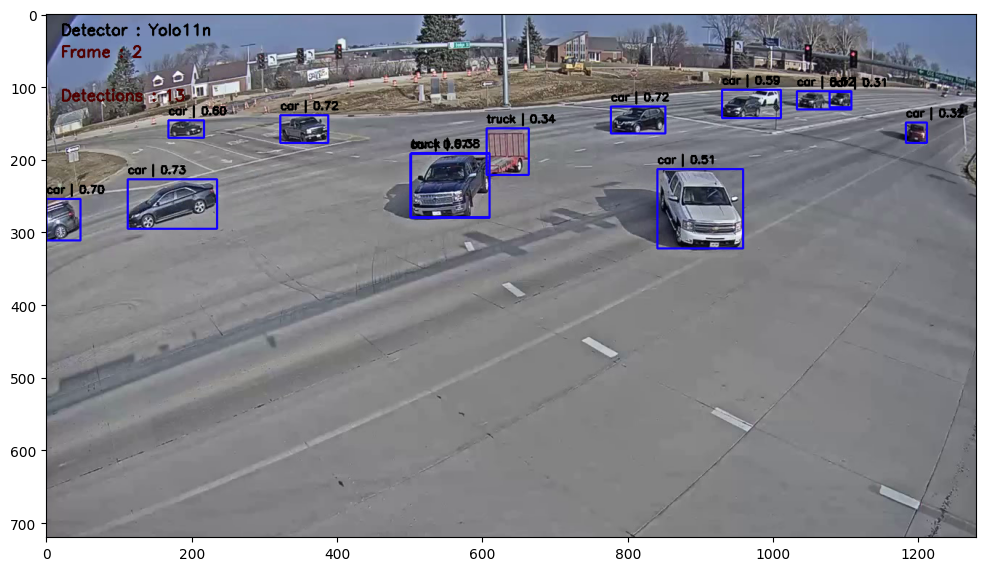

In [53]:
# Detection
from src.detection.ultralytics_detector import UltralyticsDetector

yolo_initialized = UltralyticsDetector(config)
yolo_detections = yolo_initialized.detect(frame2)

output_path = Path("outputs/test/yolo11n.mp4")
fps = 30
frame_width = 1280
frame_height = 720
detector_name = "Yolo11n"

# Visualization
from src.visualization.detector_visualizer import BenchmarkVisualizer

visualization_initialized = BenchmarkVisualizer(output_path, fps, frame_width, frame_height, detector_name)
annotated_frame2 = visualization_initialized.draw(frame2, yolo_detections, fps, 2)

plt.figure(figsize=(12, 8))
frame = cv2.cvtColor(annotated_frame2, cv2.COLOR_BGR2RGB)
plt.imshow(frame)
plt.show()

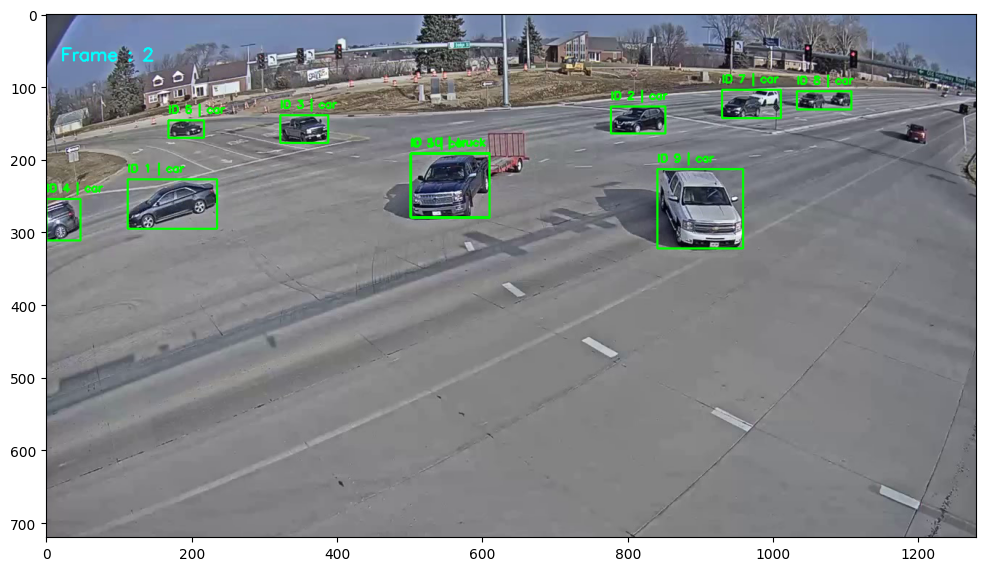

In [ ]:
# Tracking
from src.tracking.bytetrack_tracker import ByteTrackTracker

tracker_intialized = ByteTrackTracker(config)
tracks = tracker_intialized.update(yolo_detections)

# Visualization
from src.visualization.visualizer import Visualizer

visualization_initialized = Visualizer(
    show_labels = True,
    show_track_id = True,
    output_video = output_path,
    fps = fps,
    frame_width = frame_width,
    frame_height = frame_height,
)
visualization_initialized

full_annotated_frame2 = visualization_initialized.draw_tracks(frame2, tracks, frame_number = 2)

plt.figure(figsize=(12, 8))
frame = cv2.cvtColor(full_annotated_frame2, cv2.COLOR_BGR2RGB)
plt.imshow(frame)
plt.show()